In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools


#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score


from multiprocessing import Pool, cpu_count

import dask
import dask.dataframe as dd
from dask.distributed import Client
#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

In [2]:
pd.set_option('display.max_columns', None)

### Define Weighing Function

In [3]:
def mu_helper(j, delta):
    assert isinstance(delta, int) and delta >= 2, "delta must be integer larger than 2"
    
    numerator = np.sum([i - (delta-1)*0.5 for i in range(j, delta)])
    denominator = np.sum([i*(i-(delta-1)*0.5) for i in range(delta)])
    
    weight = numerator/denominator
    
    return weight

def mu(delta):
    return np.asarray([mu_helper(j, delta) for j in range(1, delta)])

In [4]:
delta_weights = {}
delta_list = [2,3,4,7,14]
for delta in delta_list:
    delta_weights[delta] = mu(delta)
    print("Weights for delta={} are {}".format(delta,delta_weights[delta]))

Weights for delta=2 are [1.]
Weights for delta=3 are [0.5 0.5]
Weights for delta=4 are [0.3 0.4 0.3]
Weights for delta=7 are [0.10714286 0.17857143 0.21428571 0.21428571 0.17857143 0.10714286]
Weights for delta=14 are [0.02857143 0.05274725 0.07252747 0.08791209 0.0989011  0.10549451
 0.10769231 0.10549451 0.0989011  0.08791209 0.07252747 0.05274725
 0.02857143]


### Reimport Historical TLGRF Estimates

In [5]:
merged_TLGRF_results = dd.read_csv("../../data/output/merged_TLGRF_results_df.csv", assume_missing=True).compute()

In [6]:
merged_TLGRF_results.columns

Index(['fips', 'county_x', 'state_x', 'date.x', 'weekly new cases',
       'days_from_start', 'log_rolled_cases.x.x', 't0.hat', 'tau.hat',
       'predicted.grf.future',
       ...
       'F_NOVEH', 'F_GROUPQ', 'F_THEME4', 'F_TOTAL', 'E_UNINSUR', 'EP_UNINSUR',
       'MP_UNINSUR', 'E_DAYPOP', 'log_rolled_cases',
       'shifted_log_rolled_cases'],
      dtype='object', length=137)

### Generate Composite `r_TLGRF(delta)` and subsequent predictions

In [7]:
cols_to_keep = ["fips", "county_x", "state_x", "date.x", "days_from_start", "tau.hat", "log_rolled_cases", "shifted_log_rolled_cases", "predicted.grf.future.last"]
kept_merged_TLGRF_results = merged_TLGRF_results[cols_to_keep]
kept_merged_TLGRF_results["date.x"] = pd.to_datetime(kept_merged_TLGRF_results["date.x"])
# Generate the past 13 days of r
for i in range(0,14):
    col_name = "tau.hat_{}_days_before".format(i)
    kept_merged_TLGRF_results[col_name] = kept_merged_TLGRF_results.groupby("fips")["tau.hat"].shift(i)
# Gnerate the composite TLGRF_r(delta) and the prediction 7 days later
for delta in delta_list:
    col_name = "r_TLGRF_delta={}".format(delta)
    kept_merged_TLGRF_results[col_name] = 0
    rs = kept_merged_TLGRF_results[["tau.hat_{}_days_before".format(i) for i in range(delta-1)]].values
    kept_merged_TLGRF_results[col_name] = rs @ delta_weights[delta]
    
    kept_merged_TLGRF_results["TLGRF_delta={}_predicted_log_rolled_cases".format(delta)] = kept_merged_TLGRF_results[col_name] * 7 + kept_merged_TLGRF_results["log_rolled_cases"]

kept_merged_TLGRF_results = kept_merged_TLGRF_results.dropna(subset=["TLGRF_delta={}_predicted_log_rolled_cases".format(delta_list[-1])])

/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/home/zwang937/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

In [8]:
kept_merged_TLGRF_results.head()

,fips,county_x,state_x,date.x,days_from_start,tau.hat,log_rolled_cases,shifted_log_rolled_cases,predicted.grf.future.last,tau.hat_0_days_before,tau.hat_1_days_before,tau.hat_2_days_before,tau.hat_3_days_before,tau.hat_4_days_before,tau.hat_5_days_before,tau.hat_6_days_before,tau.hat_7_days_before,tau.hat_8_days_before,tau.hat_9_days_before,tau.hat_10_days_before,tau.hat_11_days_before,tau.hat_12_days_before,tau.hat_13_days_before,r_TLGRF_delta=2,TLGRF_delta=2_predicted_log_rolled_cases,r_TLGRF_delta=3,TLGRF_delta=3_predicted_log_rolled_cases,r_TLGRF_delta=4,TLGRF_delta=4_predicted_log_rolled_cases,r_TLGRF_delta=7,TLGRF_delta=7_predicted_log_rolled_cases,r_TLGRF_delta=14,TLGRF_delta=14_predicted_log_rolled_cases
12,1001.0,Autauga,Alabama,2020-04-29,99.0,0.029698,3.274446,3.424728,3.482332,0.029698,0.025599,0.026393,0.024850,0.032136,0.035197,0.016528,0.014588,0.012541,0.021026,0.018760,0.010264,0.026873,NaN,0.029698,3.482332,0.027648,3.467985,0.027067,3.463913,0.028243,3.472148,0.022266,3.430309
13,1001.0,Autauga,Alabama,2020-04-30,100.0,0.032027,3.311585,3.452253,3.535773,0.032027,0.029698,0.025599,0.026393,0.024850,0.032136,0.035197,0.016528,0.014588,0.012541,0.021026,0.018760,0.010264,0.026873,0.032027,3.535773,0.030862,3.527622,0.029167,3.515754,0.027756,3.505879,0.023393,3.475337
14,1001.0,Autauga,Alabama,2020-05-01,101.0,-0.011272,3.306363,3.526361,3.227463,-0.011272,0.032027,0.029698,0.025599,0.026393,0.024850,0.032136,0.035197,0.016528,0.014588,0.012541,0.021026,0.018760,0.010264,-0.011272,3.227463,0.010378,3.379007,0.018339,3.434734,0.023736,3.472517,0.023649,3.471906
15,1001.0,Autauga,Alabama,2020-05-02,102.0,0.019009,3.321948,3.583519,3.455013,0.019009,-0.011272,0.032027,0.029698,0.025599,0.026393,0.024850,0.032136,0.035197,0.016528,0.014588,0.012541,0.021026,0.018760,0.019009,3.455013,0.003869,3.349030,0.010802,3.397564,0.020650,3.466496,0.023519,3.486579
16,1001.0,Autauga,Alabama,2020-05-03,103.0,0.021458,3.342357,3.659892,3.492561,0.021458,0.019009,-0.011272,0.032027,0.029698,0.025599,0.026393,0.024850,0.032136,0.035197,0.016528,0.014588,0.012541,0.021026,0.021458,3.492561,0.020234,3.483992,0.010660,3.416974,0.018187,3.469667,0.023314,3.505557


### Evaluate Daily Mean RMSE and MAE

In [9]:
TLGRF_delta_performance = pd.DataFrame()
for delta in delta_list:
    TLGRF_delta_RMSE = kept_merged_TLGRF_results.groupby("date.x").apply(lambda x: mean_squared_error(x['shifted_log_rolled_cases'], x['TLGRF_delta={}_predicted_log_rolled_cases'.format(delta)], squared=False))
    TLGRF_delta_MAE = kept_merged_TLGRF_results.groupby("date.x").apply(lambda x: mean_absolute_error(x['shifted_log_rolled_cases'], x['TLGRF_delta={}_predicted_log_rolled_cases'.format(delta)]))
    
    TLGRF_delta_performance["RMSE_delta={}".format(delta)] = TLGRF_delta_RMSE
    TLGRF_delta_performance["MAE_delta={}".format(delta)] = TLGRF_delta_MAE

In [10]:
TLGRF_delta_performance

,RMSE_delta=2,MAE_delta=2,RMSE_delta=3,MAE_delta=3,RMSE_delta=4,MAE_delta=4,RMSE_delta=7,MAE_delta=7,RMSE_delta=14,MAE_delta=14
date.x,,,,,,,,,,
2020-03-24,0.661267,0.610915,0.742491,0.675038,0.764855,0.693170,0.754436,0.705827,0.719264,0.711164
2020-03-25,0.572439,0.493444,0.639796,0.543570,0.713107,0.605772,0.779455,0.670611,0.724353,0.659847
2020-03-26,0.615956,0.545751,0.640915,0.548496,0.696325,0.584778,0.849109,0.695152,0.794498,0.699664
2020-03-27,0.575281,0.547096,0.621929,0.578849,0.650045,0.589834,0.805790,0.693213,0.843861,0.756675
2020-03-28,0.590071,0.567706,0.620746,0.598702,0.648891,0.621234,0.745551,0.675867,0.841216,0.737237
...,...,...,...,...,...,...,...,...,...,...
2022-12-20,0.260425,0.166655,0.273377,0.176806,0.282747,0.186164,0.283004,0.194420,0.261667,0.183877
2022-12-21,0.224934,0.146908,0.224791,0.149976,0.244638,0.164524,0.277622,0.193129,0.248132,0.188789
2022-12-22,0.230064,0.146450,0.238331,0.154007,0.237783,0.155506,0.272556,0.184222,0.250373,0.194316


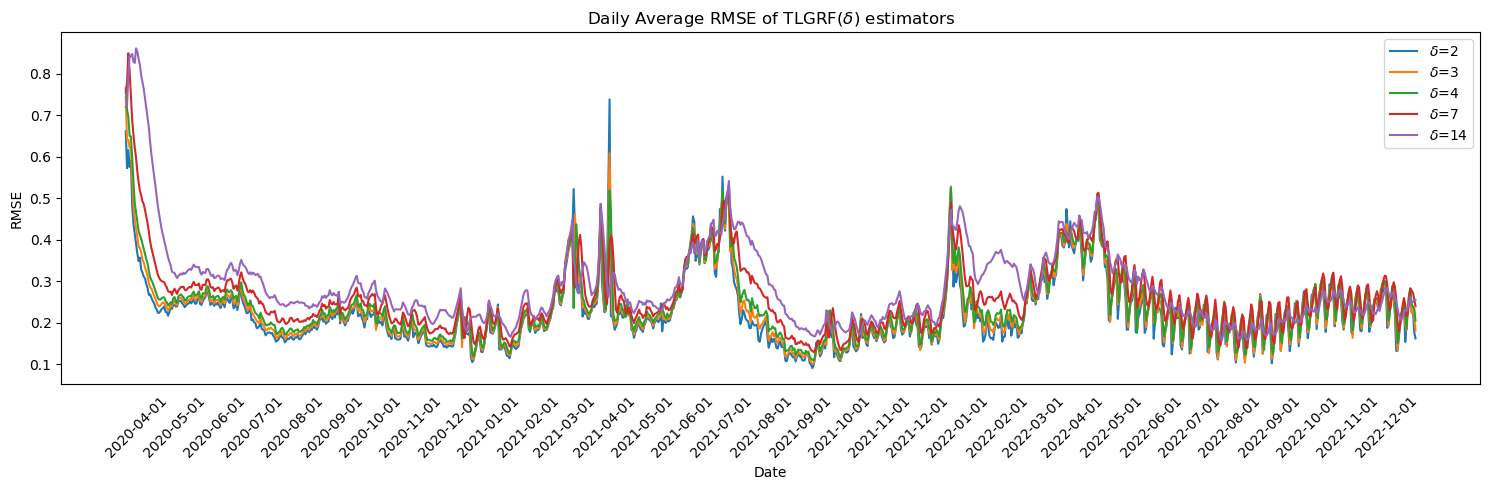

In [11]:
fig, (ax1) = plt.subplots(1, 1, figsize=(15,5))
for delta in delta_list:
    ax1.plot(TLGRF_delta_performance["RMSE_delta={}".format(delta)], label="$\delta$={}".format(delta))
ax1.set(title='Daily Average RMSE of TLGRF($\delta$) estimators', xlabel='Date', ylabel='RMSE')
ax1.set_xticks(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start])
ax1.set_xticklabels(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start].strftime('%Y-%m-%d'), rotation=45)
ax1.tick_params(axis='x', which='both', bottom=False, top=False)
ax1.legend()
plt.tight_layout()

plt.show()


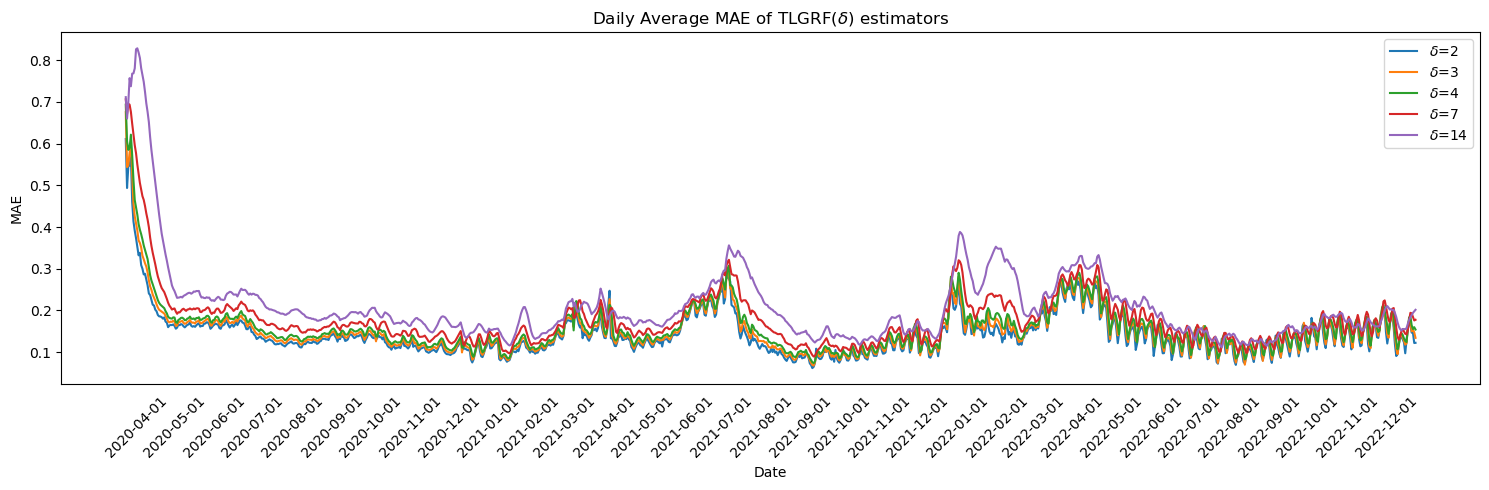

In [12]:
fig, (ax2) = plt.subplots(1, 1, figsize=(15, 5))

for delta in delta_list:
    ax2.plot(TLGRF_delta_performance["MAE_delta={}".format(delta)], label="$\delta$={}".format(delta))
ax2.set(title='Daily Average MAE of TLGRF($\delta$) estimators', xlabel='Date', ylabel='MAE')
ax2.set_xticks(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start])
ax2.set_xticklabels(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start].strftime('%Y-%m-%d'), rotation=45)
ax2.tick_params(axis='x', which='both', bottom=False, top=False)

ax2.legend()
plt.tight_layout()

plt.show()

### Plot $\delta=2$ against others

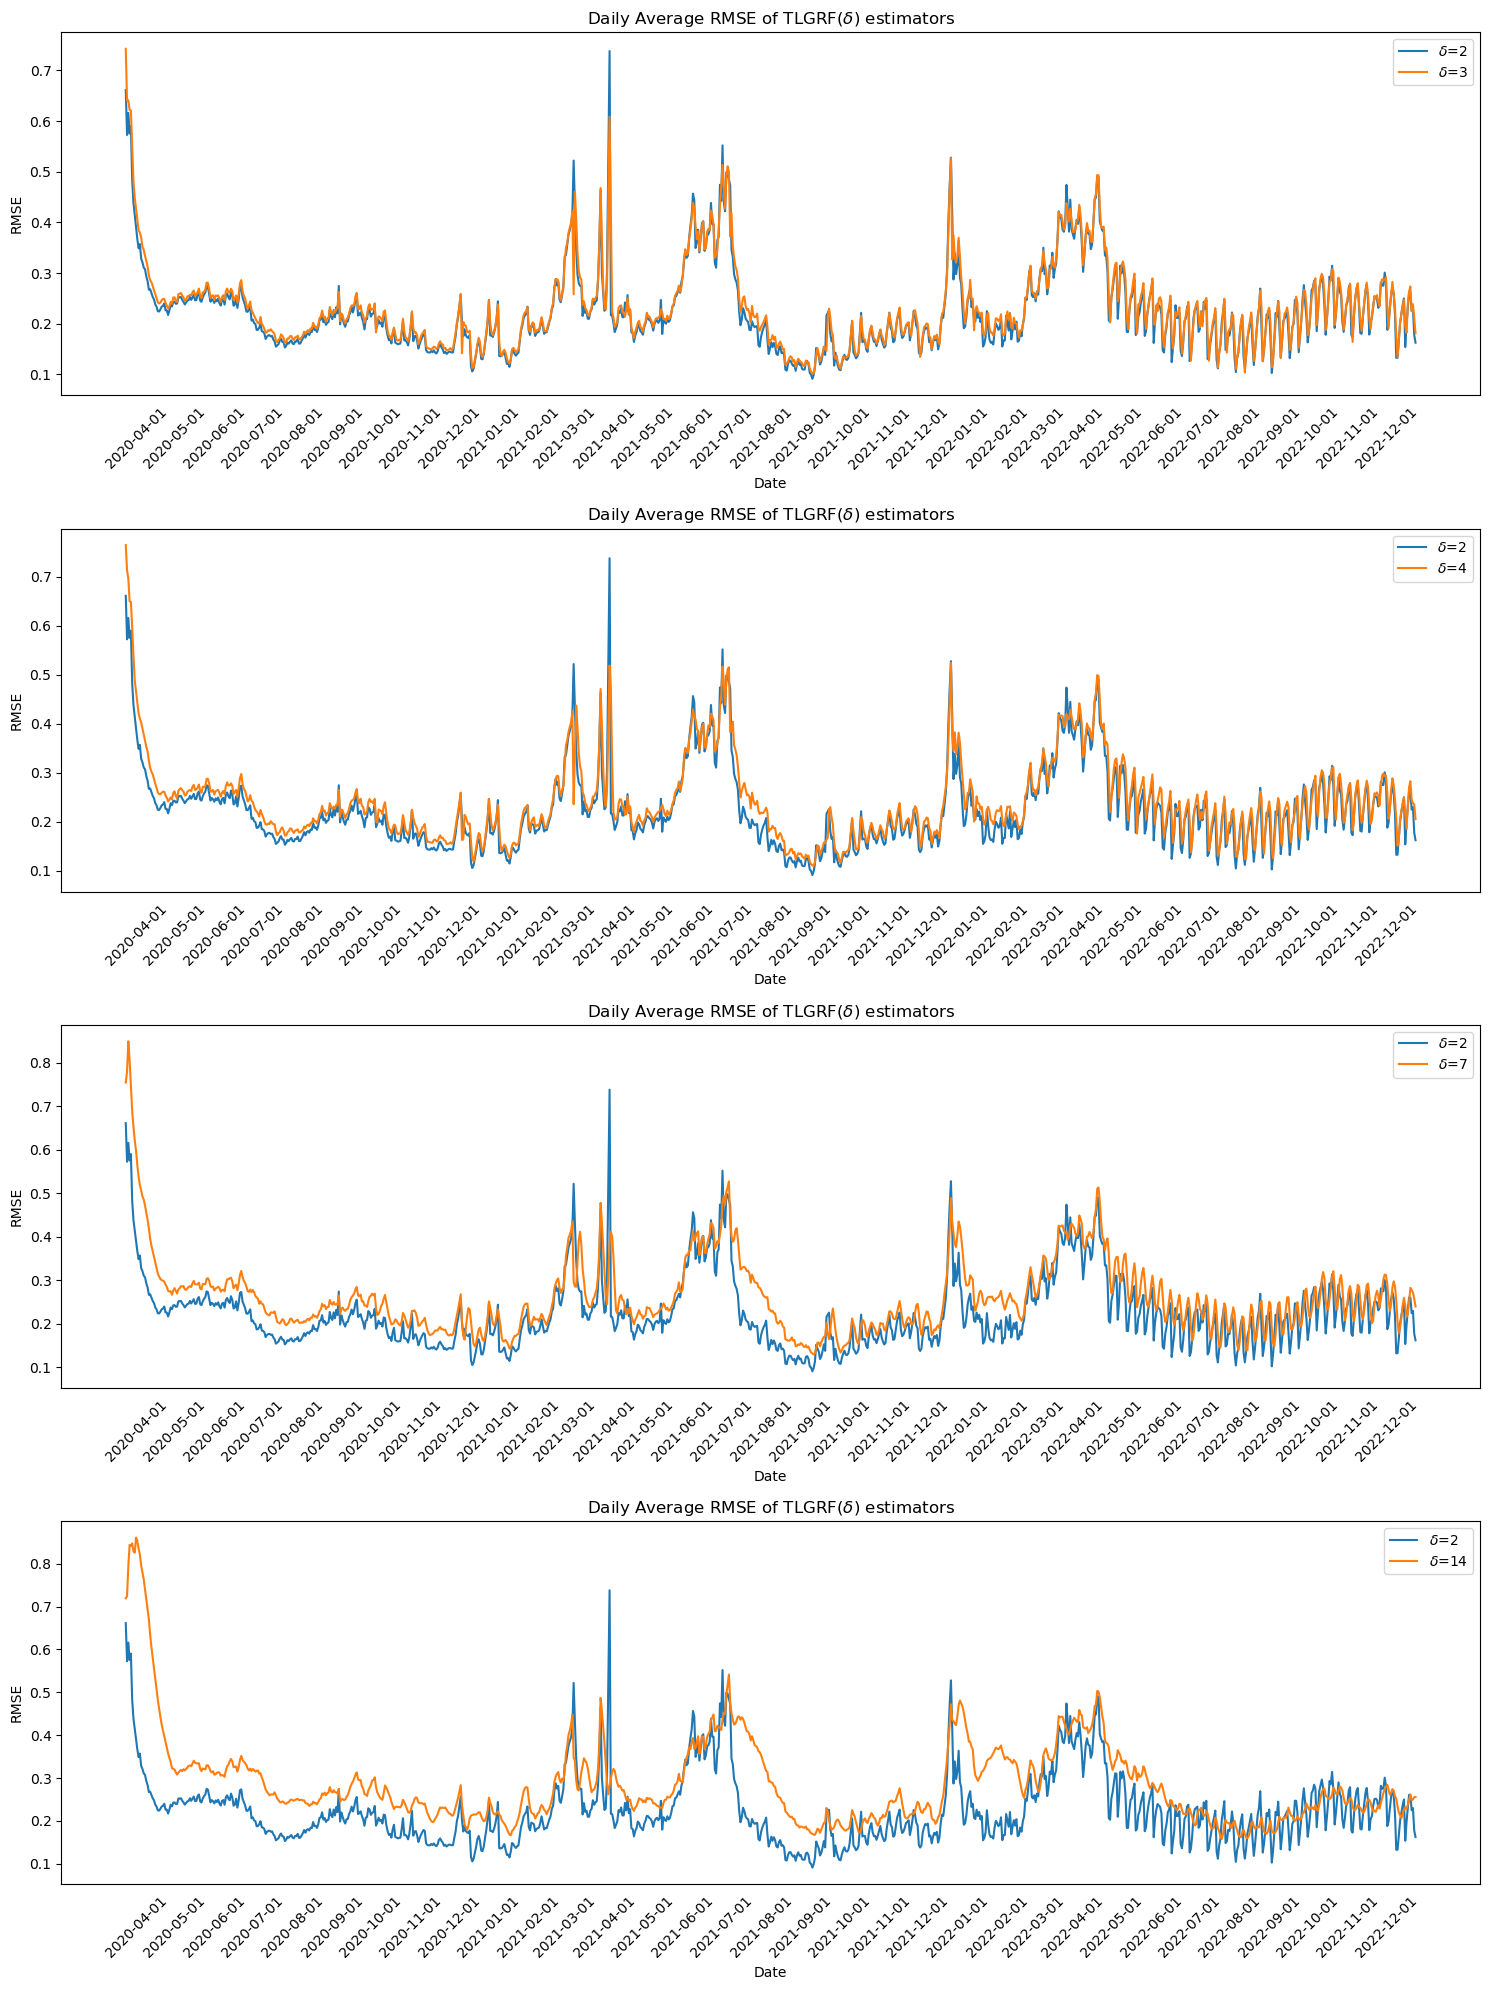

In [13]:
fig, axes = plt.subplots(len(delta_list[1:]), 1, figsize=(15,20))
for i, delta in enumerate(delta_list[1:]):
    axes[i].plot(TLGRF_delta_performance["RMSE_delta={}".format(2)], label="$\delta$={}".format(2))
    axes[i].plot(TLGRF_delta_performance["RMSE_delta={}".format(delta)], label="$\delta$={}".format(delta))
    axes[i].set(title='Daily Average RMSE of TLGRF($\delta$) estimators', xlabel='Date', ylabel='RMSE')
    axes[i].set_xticks(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start])
    axes[i].set_xticklabels(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start].strftime('%Y-%m-%d'), rotation=45)
    axes[i].tick_params(axis='x', which='both', bottom=False, top=False)
    axes[i].legend()
plt.tight_layout()

plt.show()


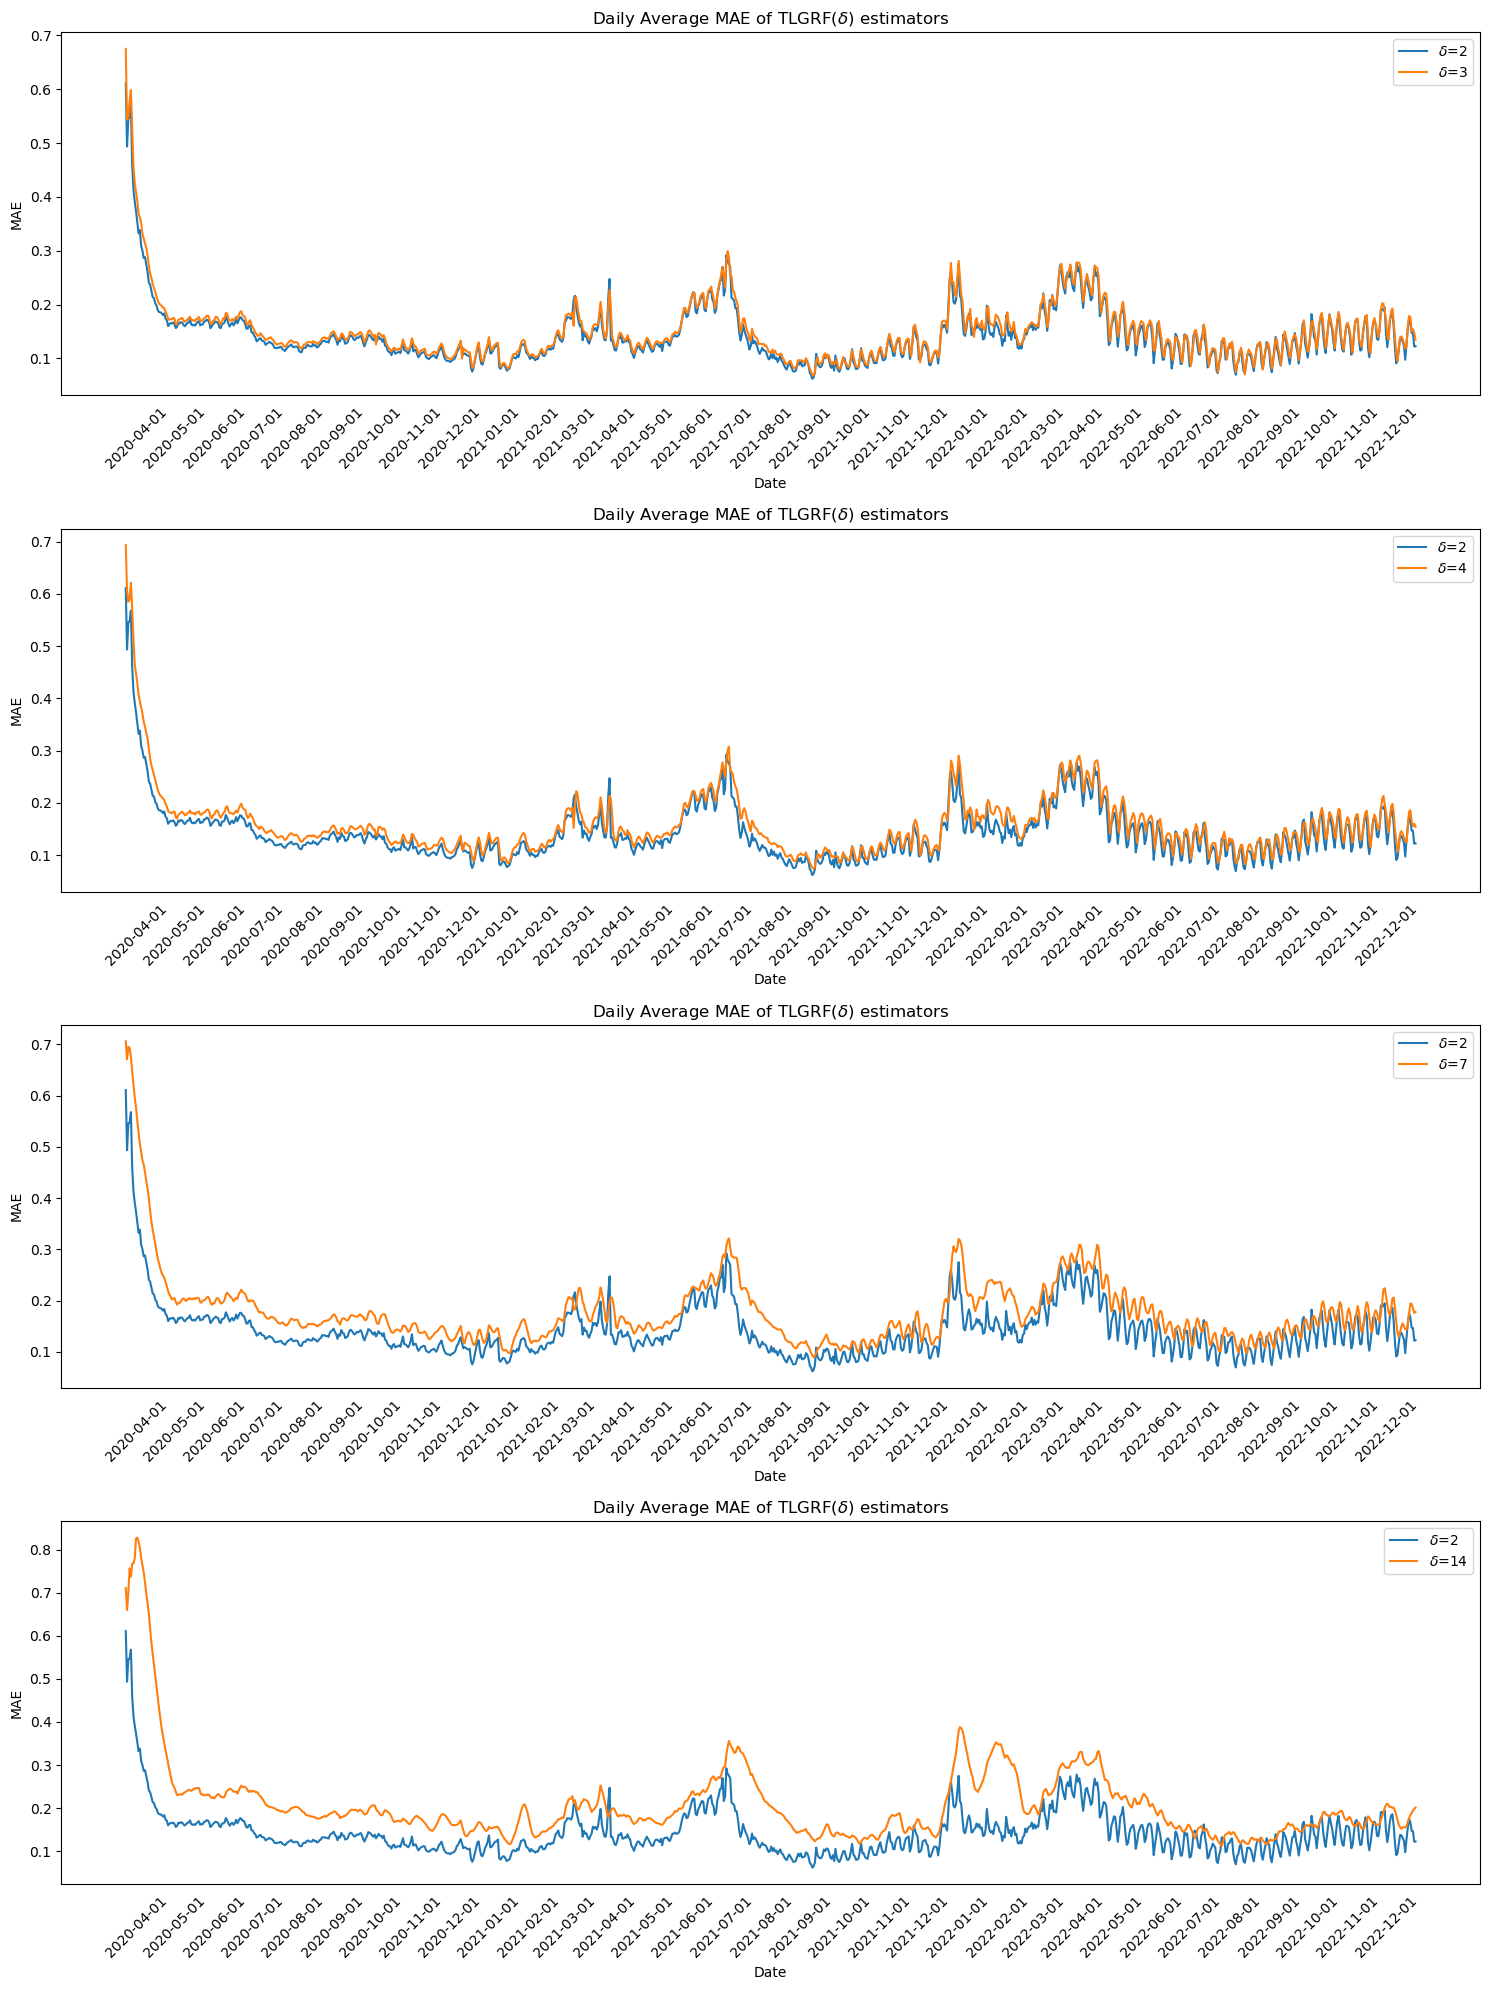

In [14]:
fig, axes = plt.subplots(len(delta_list[1:]), 1, figsize=(15,20))
for i, delta in enumerate(delta_list[1:]):
    axes[i].plot(TLGRF_delta_performance["MAE_delta={}".format(2)], label="$\delta$={}".format(2))
    axes[i].plot(TLGRF_delta_performance["MAE_delta={}".format(delta)], label="$\delta$={}".format(delta))
    axes[i].set(title='Daily Average MAE of TLGRF($\delta$) estimators', xlabel='Date', ylabel='MAE')
    axes[i].set_xticks(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start])
    axes[i].set_xticklabels(TLGRF_delta_performance.index[TLGRF_delta_performance.index.is_month_start].strftime('%Y-%m-%d'), rotation=45)
    axes[i].tick_params(axis='x', which='both', bottom=False, top=False)
    axes[i].legend()
plt.tight_layout()

plt.show()

### Table of Median of Daily RMSE and MAE for each Delta

In [15]:
TLGRF_delta_performance_pivot = TLGRF_delta_performance.copy()
TLGRF_delta_performance_dict = {}

TLGRF_delta_performance_dict["$\delta$"] = delta_list
TLGRF_delta_performance_dict["Median MAE"] = [TLGRF_delta_performance_pivot["MAE_delta={}".format(delta)].median() for delta in delta_list]
TLGRF_delta_performance_dict["Median RMSE"] = [TLGRF_delta_performance_pivot["RMSE_delta={}".format(delta)].median() for delta in delta_list]
TLGRF_delta_performance_dict

TLGRF_delta_performance_pivot = pd.DataFrame(TLGRF_delta_performance_dict)
TLGRF_delta_performance_pivot = TLGRF_delta_performance_pivot.sort_values(by="$\delta$", ascending=False)
TLGRF_delta_performance_pivot
#TLGRF_pivot_table = TLGRF_delta_performance.pivot_table(index=TLGRF_delta_performance.index, columns='delta', aggfunc='median')
#TLGRF_pivot_table.index = ['MAE', 'RMSE']
#TLGRF_pivot_table
print(TLGRF_delta_performance_pivot.to_string(index=False))

 $\delta$  Median MAE  Median RMSE
       14    0.185958     0.258874
        7    0.161461     0.244550
        4    0.143881     0.223977
        3    0.137439     0.216248
        2    0.131463     0.208511


In [16]:
display(TLGRF_delta_performance_pivot)

,$\delta$,Median MAE,Median RMSE
4,14,0.185958,0.258874
3,7,0.161461,0.244550
2,4,0.143881,0.223977
1,3,0.137439,0.216248
0,2,0.131463,0.208511


In [17]:
latex_table = TLGRF_delta_performance_pivot.to_latex(index=False, column_format='c|c|c', escape=False, header=['$\delta$', 'Median MAE', 'Median RMSE'])
centered_table = '\\begin{center}\n' + latex_table + '\\end{center}'


In [18]:
pprint(centered_table)

('\\begin{center}\n'
 '\\begin{tabular}{c|c|c}\n'
 '\\toprule\n'
 '$\\delta$ & Median MAE & Median RMSE \\\\\n'
 '\\midrule\n'
 '      14 &   0.185958 &    0.258874 \\\\\n'
 '       7 &   0.161461 &    0.244550 \\\\\n'
 '       4 &   0.143881 &    0.223977 \\\\\n'
 '       3 &   0.137439 &    0.216248 \\\\\n'
 '       2 &   0.131463 &    0.208511 \\\\\n'
 '\\bottomrule\n'
 '\\end{tabular}\n'
 '\\end{center}')
